## Exploratory Data Analysis on S&P 500 Subset

This section provides an overview and basic statistics for the subset of S&P 500 companies (top 3 by weight in each sector).

In [39]:
import pandas as pd
import numpy as np

# Load data

sectors_wgts = pd.read_csv("../data/sp500_wgts_sectors.csv")
sp500_subset = pd.read_csv("../data/sp500_subset.csv")

# Clean symbols
sectors_wgts["Symbol"] = sectors_wgts["Symbol"].astype(str).str.strip()
sp500_subset["Symbol"] = sp500_subset["Symbol"].astype(str).str.strip()

# Ensure Date is datetime
sp500_subset["Date"] = pd.to_datetime(sp500_subset["Date"])


In [40]:
# Merge weights into price data

sp500_subset = sp500_subset.merge(
    sectors_wgts[["Symbol", "Weight"]],
    on="Symbol",
    how="left",
    validate="many_to_one"   # ensures weights only appear once per symbol
)


In [41]:
sp500_subset.head()


,Date,Close,High,Low,Open,Volume,Symbol,Security,Sector,Weight
0,2020-11-23,84.081802,84.559074,83.168406,83.884313,7541500,ABBV,AbbVie,Health Care,0.007
1,2020-11-24,85.546516,86.254193,84.410945,84.657805,9322200,ABBV,AbbVie,Health Care,0.007
2,2020-11-25,85.744026,85.957977,85.077496,85.431334,6368100,ABBV,AbbVie,Health Care,0.007
3,2020-11-27,86.311798,87.060621,85.826302,86.385860,4418800,ABBV,AbbVie,Health Care,0.007
4,2020-11-30,86.056725,86.747940,85.291446,86.501080,20726500,ABBV,AbbVie,Health Care,0.007


In [42]:
sectors_wgts.head()

,Symbol,Security,Sector,Weight
0,MMM,3M,Industrials,0.0015
1,AOS,A. O. Smith,Industrials,0.0002
2,ABT,Abbott Laboratories,Health Care,0.0037
3,ABBV,AbbVie,Health Care,0.0070
4,ACN,Accenture,Information Technology,0.0026


In [43]:
# Quick checks

# S&P 500 Subset (Price Data)

print("Price data shape:", sp500_subset.shape)
print("\nColumns in price data:", sp500_subset.columns)
print("\nDate range:")
print("Min:", sp500_subset["Date"].min(), "| Max:", sp500_subset["Date"].max())
print("\nNumber of symbols in price subset:", sp500_subset["Symbol"].nunique())
print("\nMissing values:")
print(sp500_subset.isna().sum())

Price data shape: (41125, 10)

Columns in price data: Index(['Date', 'Close', 'High', 'Low', 'Open', 'Volume', 'Symbol', 'Security',
       'Sector', 'Weight'],
      dtype='object')

Date range:
Min: 2020-11-23 00:00:00 | Max: 2025-11-20 00:00:00

Number of symbols in price subset: 33

Missing values:
Date        0
Close       0
High        0
Low         0
Open        0
Volume      0
Symbol      0
Security    0
Sector      0
Weight      0
dtype: int64


In [44]:
# Weights and Sectors Data

print("Weight data shape:", sectors_wgts.shape)
print("\nColumns in weight data:", sectors_wgts.columns)
print("Number of sectors in weight dataset:", sectors_wgts["Sector"].nunique())
print("\nMissing values:")
print(sectors_wgts.isna().sum())

Weight data shape: (503, 4)

Columns in weight data: Index(['Symbol', 'Security', 'Sector', 'Weight'], dtype='object')
Number of sectors in weight dataset: 11

Missing values:
Symbol      0
Security    0
Sector      0
Weight      0
dtype: int64


In [45]:
print(sp500_subset.head())
print(sp500_subset.isna().sum())

missing = sp500_subset[sp500_subset["Weight"].isna()]["Symbol"].unique()
print("Symbols missing weights:", missing)

        Date      Close       High        Low       Open    Volume Symbol  \
0 2020-11-23  84.081802  84.559074  83.168406  83.884313   7541500   ABBV   
1 2020-11-24  85.546516  86.254193  84.410945  84.657805   9322200   ABBV   
2 2020-11-25  85.744026  85.957977  85.077496  85.431334   6368100   ABBV   
3 2020-11-27  86.311798  87.060621  85.826302  86.385860   4418800   ABBV   
4 2020-11-30  86.056725  86.747940  85.291446  86.501080  20726500   ABBV   

  Security       Sector  Weight  
0   AbbVie  Health Care   0.007  
1   AbbVie  Health Care   0.007  
2   AbbVie  Health Care   0.007  
3   AbbVie  Health Care   0.007  
4   AbbVie  Health Care   0.007  
Date        0
Close       0
High        0
Low         0
Open        0
Volume      0
Symbol      0
Security    0
Sector      0
Weight      0
dtype: int64
Symbols missing weights: []


In [46]:
# Total sum of weights from S&P 500 subset

unique_securities = (
    sp500_subset[["Symbol", "Security", "Sector", "Weight"]]
    .drop_duplicates("Symbol")
    .sort_values("Weight", ascending=False)
)

sum_weights = unique_securities["Weight"].sum()
print(f"Total sum of weights in subset: {sum_weights*100:.2f}%")

Total sum of weights in subset: 49.96%


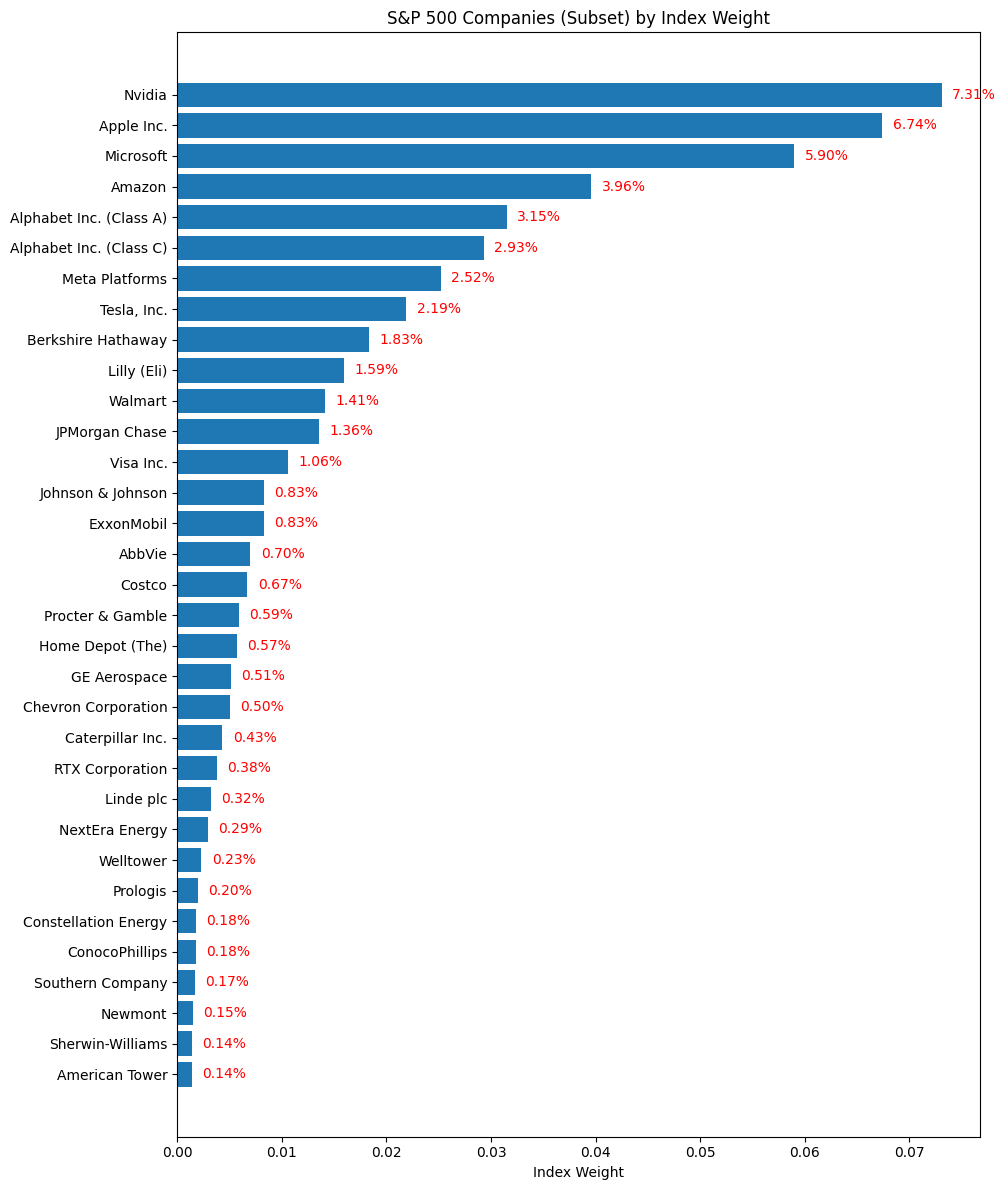

In [47]:
# Plot all S&P 500 Subset companies by weight with % labels

import matplotlib.pyplot as plt

plt.figure(figsize=(10, 12))
bars = plt.barh(
    unique_securities["Security"],
    unique_securities["Weight"]
)
plt.gca().invert_yaxis()
plt.title("S&P 500 Companies (Subset) by Index Weight")
plt.xlabel("Index Weight")
plt.tight_layout()

# Add % labels in red at the end of each bar
for bar, weight in zip(bars, unique_securities["Weight"]):
    plt.text(
        bar.get_width() + 0.001,  # Slightly after the end of the bar
        bar.get_y() + bar.get_height() / 2,
        f"{weight*100:.2f}%",
        va='center',
        ha='left',
        color='red',
        fontsize=10
    )

plt.show()


In [48]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Set seed for reproducibility
np.random.seed(42)

# Number of sectors to randomly include
X = 5   # <-- change this number to pick 5 sectors, or 3, or 8, etc.

# Get unique sectors
all_sectors = sorted(sp500_subset["Sector"].unique())

# Randomly pick X sectors
chosen_sectors = np.random.choice(all_sectors, size=X, replace=False)
print("Randomly selected sectors:", chosen_sectors)

# Filter to only those sectors
filtered = sp500_subset[sp500_subset["Sector"].isin(chosen_sectors)]

# Pick 1 random company for each chosen sector
unique_sec = filtered[["Symbol", "Sector"]].drop_duplicates()

selected_symbols = (
    unique_sec
    .groupby("Sector")["Symbol"]
    .apply(lambda x: np.random.choice(list(x), 1)[0])
)

print("\nRandomly selected companies from these sectors:")
print(selected_symbols)


Randomly selected sectors: ['Health Care' 'Communication Services' 'Real Estate' 'Utilities'
 'Consumer Staples']

Randomly selected companies from these sectors:
Sector
Communication Services    GOOGL
Consumer Staples            WMT
Health Care                 JNJ
Real Estate                 AMT
Utilities                   NEE
Name: Symbol, dtype: object


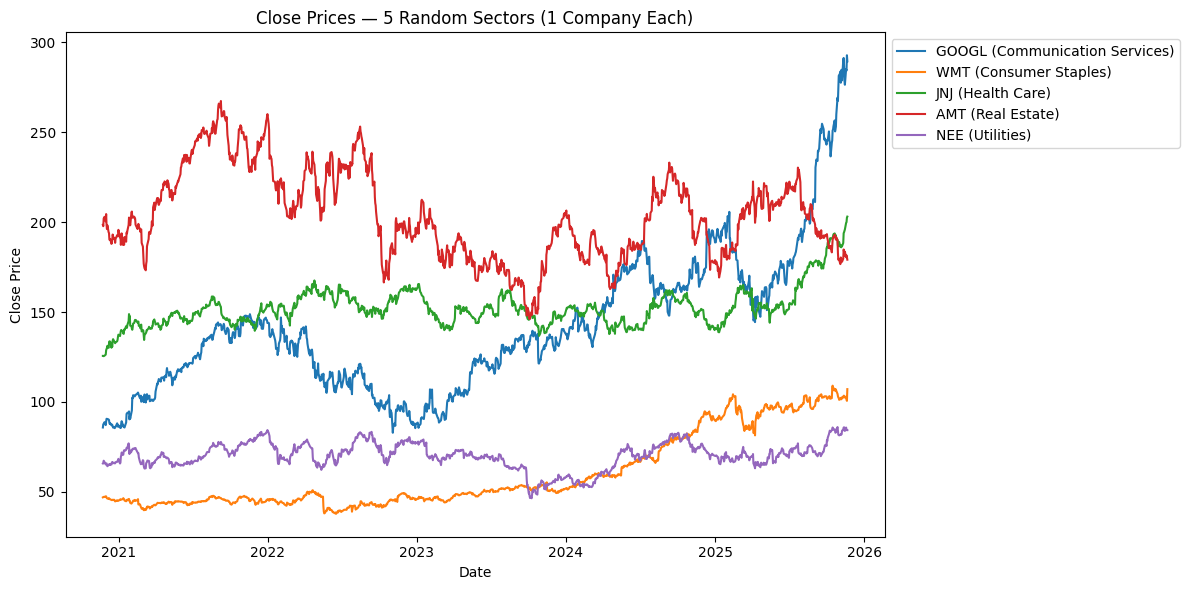

In [49]:
# Plot Close prices 

import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))

for sym in selected_symbols:
    sub = filtered[filtered["Symbol"] == sym]
    plt.plot(sub["Date"], sub["Close"], label=f"{sym} ({sub['Sector'].iloc[0]})")

plt.title(f"Close Prices — {X} Random Sectors (1 Company Each)")
plt.xlabel("Date")
plt.ylabel("Close Price")
plt.legend(loc="upper left", bbox_to_anchor=(1, 1))
plt.tight_layout()
plt.show()



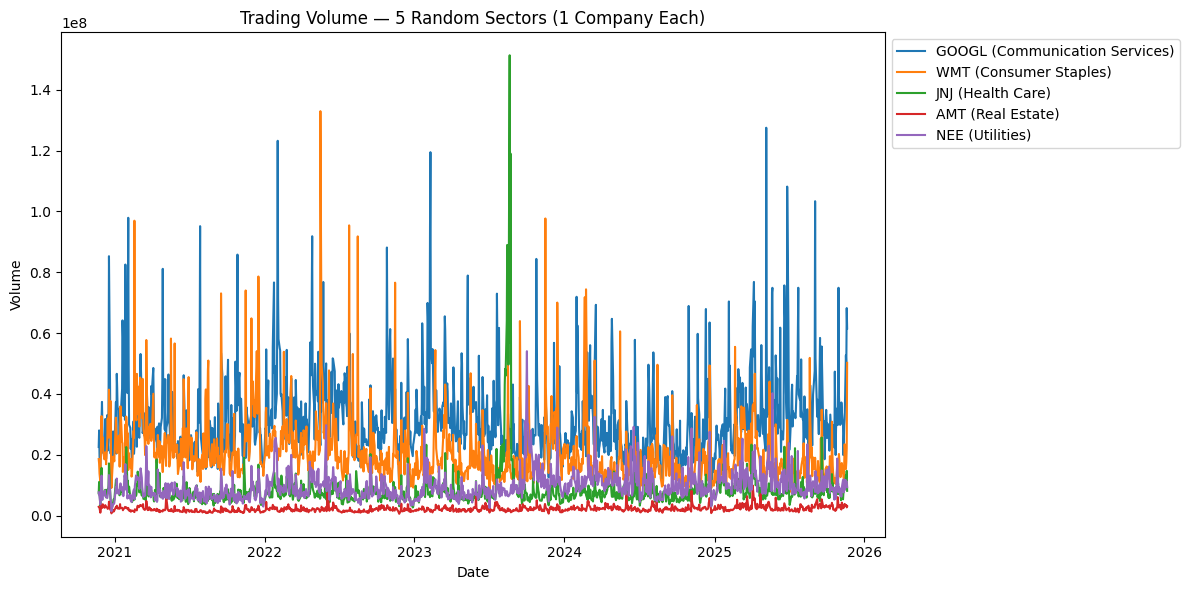

In [50]:
# Plot Volume

import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))

for sym in selected_symbols:
    sub = filtered[filtered["Symbol"] == sym]
    plt.plot(sub["Date"], sub["Volume"], label=f"{sym} ({sub['Sector'].iloc[0]})")

plt.title(f"Trading Volume — {X} Random Sectors (1 Company Each)")
plt.xlabel("Date")
plt.ylabel("Volume")
plt.legend(loc="upper left", bbox_to_anchor=(1, 1))
plt.tight_layout()
plt.show()



In [51]:
# Calculate daily returns and log returns
import numpy as np

sp500_subset2 = sp500_subset.sort_values(["Symbol", "Date"]).copy()

sp500_subset2["Return"] = (
    sp500_subset2.groupby("Symbol")["Close"]
    .transform(lambda x: x.pct_change())
)

sp500_subset2["LogReturn"] = np.log1p(sp500_subset2["Return"])

sp500_subset2

,Date,Close,High,Low,Open,Volume,Symbol,Security,Sector,Weight,Return,LogReturn
6275,2020-11-23,110.827545,114.497465,110.730201,114.069143,127959300,AAPL,Apple Inc.,Information Technology,0.0674,NaN,NaN
6276,2020-11-24,112.112503,112.774451,109.600994,110.885958,113874200,AAPL,Apple Inc.,Information Technology,0.0674,0.011594,0.011528
6277,2020-11-25,112.949669,113.650556,112.112499,112.482416,76499200,AAPL,Apple Inc.,Information Technology,0.0674,0.007467,0.007439
6278,2020-11-27,113.494804,114.370913,113.134632,113.475339,46691300,AAPL,Apple Inc.,Information Technology,0.0674,0.004826,0.004815
6279,2020-11-30,115.889488,117.758515,113.708950,113.864706,169410200,AAPL,Apple Inc.,Information Technology,0.0674,0.021100,0.020880
...,...,...,...,...,...,...,...,...,...,...,...,...
16020,2025-11-14,119.290001,119.480003,116.660004,118.449997,17064300,XOM,ExxonMobil,Energy,0.0083,0.012993,0.012909
16021,2025-11-17,117.680000,119.500000,117.110001,118.970001,16034900,XOM,ExxonMobil,Energy,0.0083,-0.013497,-0.013588
16022,2025-11-18,119.029999,119.480003,116.480003,117.260002,15808500,XOM,ExxonMobil,Energy,0.0083,0.011472,0.011406
16023,2025-11-19,117.349998,118.180000,115.930000,116.849998,15919200,XOM,ExxonMobil,Energy,0.0083,-0.014114,-0.014215


In [52]:
# Weighted Summary Statistics

import numpy as np
import pandas as pd

# Assign Year + Weights
sp500_subset2["Year"] = sp500_subset2["Date"].dt.year
year_weights = {2020:0.10, 2021:0.10, 2022:0.10, 2023:0.20, 2024:0.30, 2025:0.30}
sp500_subset2["YearWeight"] = sp500_subset2["Year"].map(year_weights)

# ---- Weighted Functions ----

def weighted_mean(values, weights):
    mask = values.notna()
    v = values[mask]
    w = weights[mask]
    return np.average(v, weights=w)

def weighted_sd(values, weights):
    mask = values.notna()
    v = values[mask]
    w = weights[mask]
    mean_w = np.average(v, weights=w)
    var_w = np.average((v - mean_w)**2, weights=w)
    return np.sqrt(var_w)

# ---- Grouped weighted calculations ----

weighted_summary = sp500_subset2.groupby("Symbol").apply(
    lambda g: pd.Series({
        "W_Daily_Return": weighted_mean(g["Return"], g["YearWeight"]),
        "W_Daily_LogReturn": weighted_mean(g["LogReturn"], g["YearWeight"]),
        "W_SD_Return": weighted_sd(g["Return"], g["YearWeight"]),
        "W_SD_LogReturn": weighted_sd(g["LogReturn"], g["YearWeight"])
    })
).reset_index()

# ---- Annualizations ----

weighted_summary["W_Annual_LogReturn"] = weighted_summary["W_Daily_LogReturn"] * 252
weighted_summary["W_Annual_Return"] = np.exp(weighted_summary["W_Annual_LogReturn"]) - 1

weighted_summary["W_Annual_SD"] = weighted_summary["W_SD_Return"] * np.sqrt(252)
weighted_summary["W_Annual_LogSD"] = weighted_summary["W_SD_LogReturn"] * np.sqrt(252)
# ---- Final Clean Order ----

weighted_summary = weighted_summary[[
    "Symbol",
    "W_Daily_Return",
    "W_Daily_LogReturn",
    "W_Annual_Return",
    "W_Annual_LogReturn",
    "W_SD_Return",
    "W_SD_LogReturn",
    "W_Annual_SD",
    "W_Annual_LogSD"
]]

weighted_summary

/var/folders/sx/rlv33lyd2zs6vjp3khdjp3dc0000gn/T/ipykernel_12712/3136354118.py:29: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  weighted_summary = sp500_subset2.groupby("Symbol").apply(


,Symbol,W_Daily_Return,W_Daily_LogReturn,W_Annual_Return,W_Annual_LogReturn,W_SD_Return,W_SD_LogReturn,W_Annual_SD,W_Annual_LogSD
0,AAPL,0.000942,0.000792,0.220755,0.199470,0.017378,0.017290,0.275861,0.274473
1,ABBV,0.000894,0.000785,0.218818,0.197882,0.014606,0.014743,0.231869,0.234040
2,AMT,0.000005,-0.000125,-0.031072,-0.031565,0.016158,0.016157,0.256498,0.256488
3,AMZN,0.000895,0.000670,0.183960,0.168865,0.021234,0.021204,0.337073,0.336601
4,BRK-B,0.000710,0.000654,0.179136,0.164782,0.010579,0.010582,0.167929,0.167986
5,CAT,0.001290,0.001122,0.326867,0.282821,0.018331,0.018249,0.291000,0.289694
6,CEG,0.002671,0.002150,0.719080,0.541789,0.032447,0.032107,0.515087,0.509690
7,COP,0.000390,0.000193,0.049879,0.048675,0.019795,0.019854,0.314232,0.315179
8,COST,0.000889,0.000798,0.222629,0.201004,0.013450,0.013499,0.213516,0.214289
9,CVX,0.000424,0.000309,0.080926,0.077818,0.015167,0.015229,0.240772,0.241753


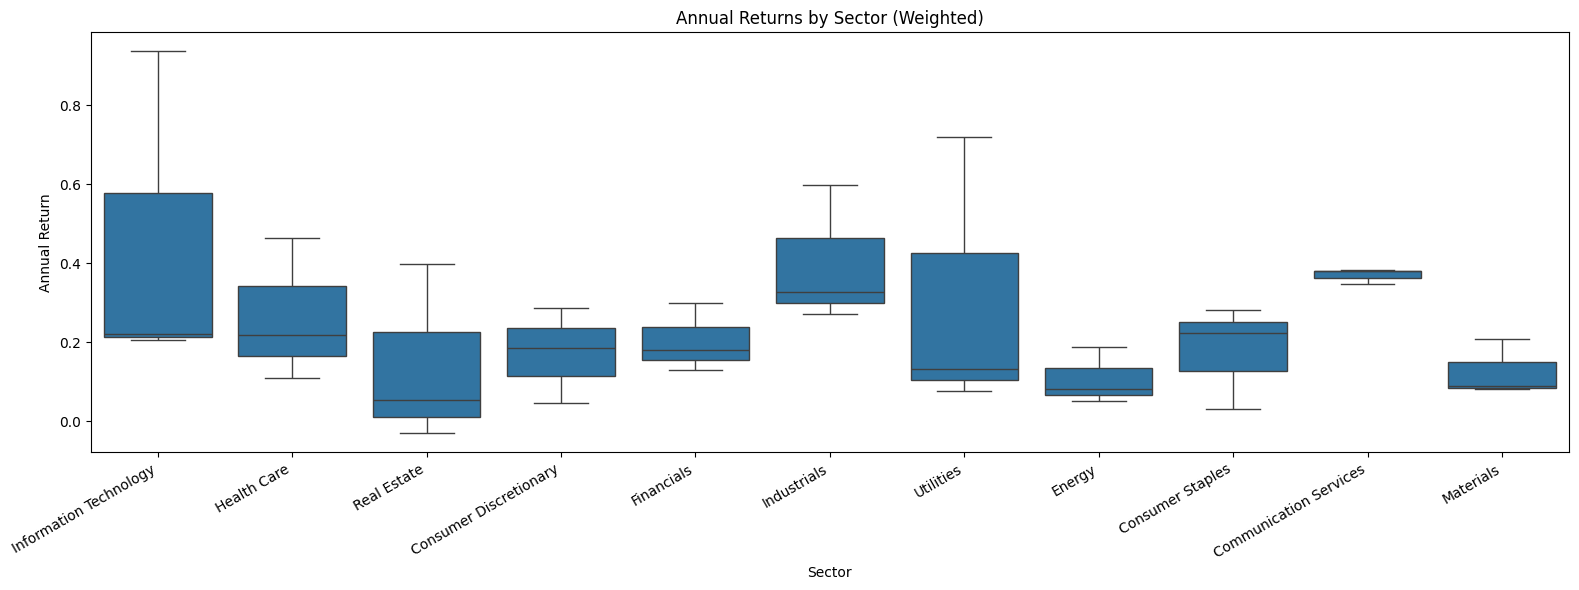

In [53]:
# Boxplot of annual log return by sector

import seaborn as sns
import matplotlib.pyplot as plt

# Attach Sector to weighted summary for boxplot
returns_df = weighted_summary.merge(
    sp500_subset2[["Symbol", "Sector"]].drop_duplicates(),
    on="Symbol",
    how="left"
)

plt.figure(figsize=(16, 6))
sns.boxplot(data=returns_df, x="Sector", y="W_Annual_Return")
plt.xticks(rotation=30, ha='right')
plt.title("Annual Returns by Sector (Weighted)")
plt.xlabel("Sector")
plt.ylabel("Annual Return")
plt.tight_layout()
plt.show()

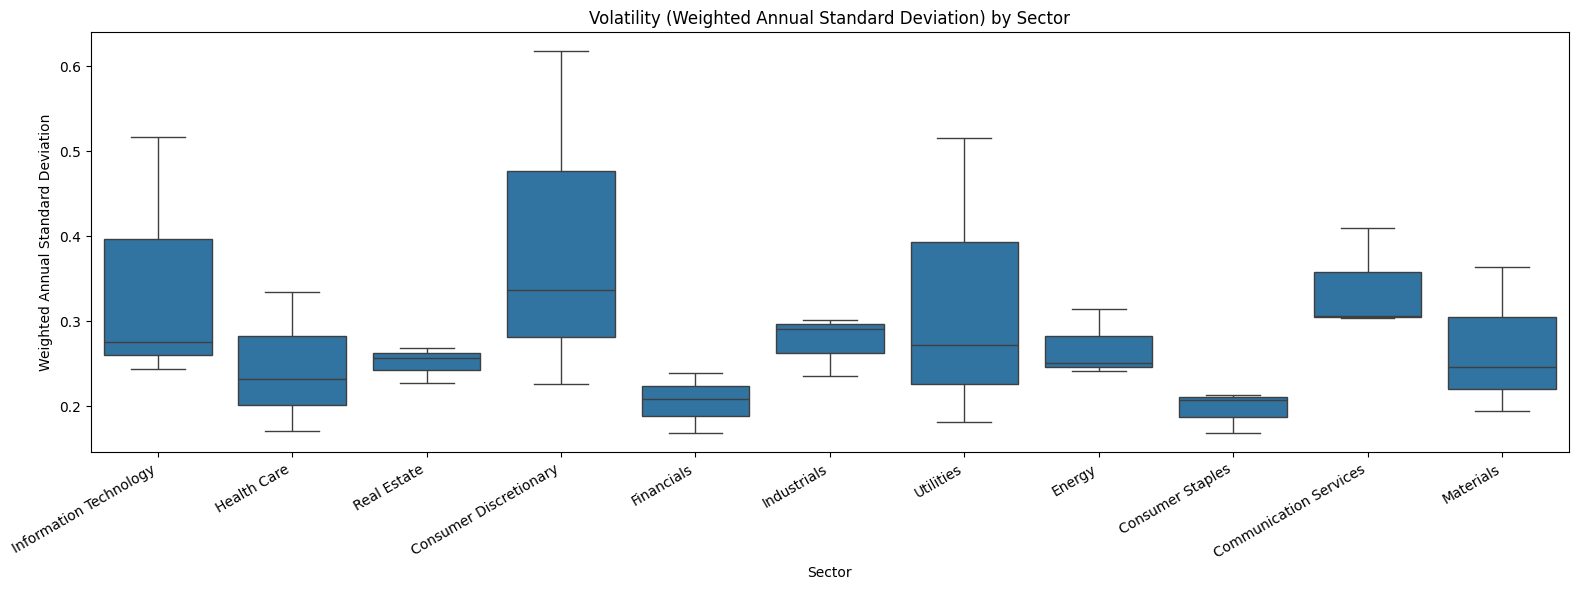

In [54]:
# Boxplot of volatility (SD of returns) by sector

import matplotlib.pyplot as plt
import seaborn as sns

# Make sure Sector column exists in weighted_summary
vol_df = weighted_summary.merge(
    sp500_subset2[["Symbol", "Sector"]].drop_duplicates(),
    on="Symbol",
    how="left"
)

plt.figure(figsize=(16, 6))
sns.boxplot(data=vol_df, x="Sector", y="W_Annual_SD")
plt.xticks(rotation=30, ha='right')
plt.title("Volatility (Weighted Annual Standard Deviation) by Sector")
plt.xlabel("Sector")
plt.ylabel("Weighted Annual Standard Deviation")
plt.tight_layout()
plt.show()


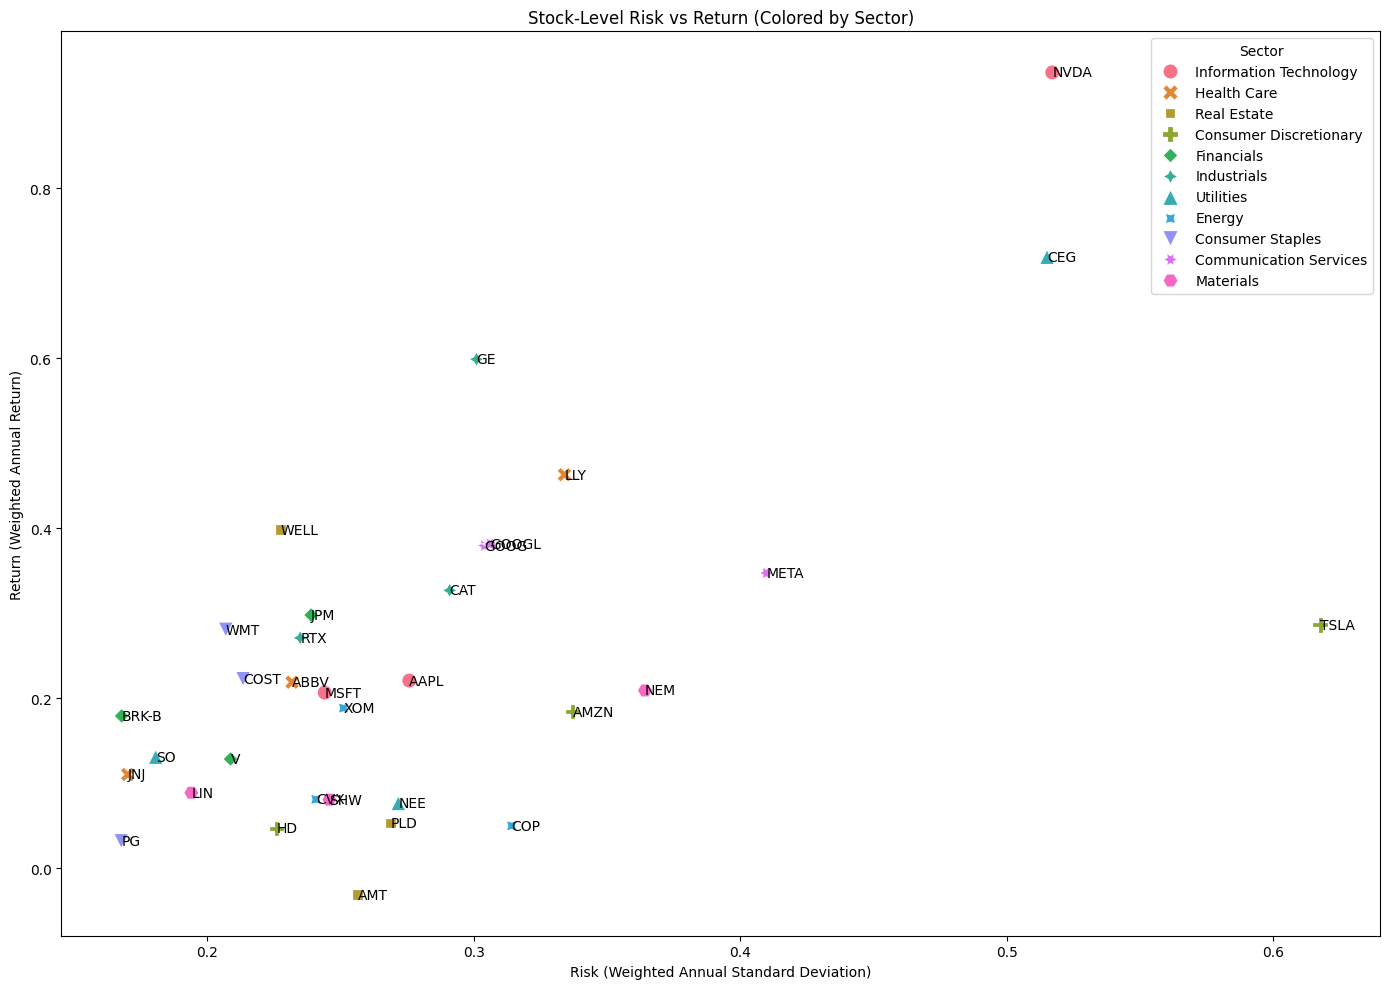

In [55]:
# Risk-Return Map By Stock
import seaborn as sns
import matplotlib.pyplot as plt

# Attach sector for coloring
df = weighted_summary.merge(
    sp500_subset2[["Symbol", "Sector"]].drop_duplicates(),
    on="Symbol",
    how="left"
)

plt.figure(figsize=(14, 10))  # Larger figure size

sns.scatterplot(
    data=df,
    x="W_Annual_SD",
    y="W_Annual_Return",
    hue="Sector",
    style="Sector",
    s=120  # Larger marker size
 )

# Label each point with stock symbol
for _, row in df.iterrows():
    plt.text(
        row["W_Annual_SD"],  # Use correct x axis
        row["W_Annual_Return"],
        row["Symbol"],
        fontsize=10,
        ha='left',
        va='center'
    )

plt.xlabel("Risk (Weighted Annual Standard Deviation)")
plt.ylabel("Return (Weighted Annual Return)")
plt.title("Stock-Level Risk vs Return (Colored by Sector)")
plt.tight_layout()
plt.show()

Sector correlation (LogReturns):


Sector,Communication Services,Consumer Discretionary,Consumer Staples,Energy,Financials,Health Care,Industrials,Information Technology,Materials,Real Estate,Utilities
Sector,,,,,,,,,,,
Communication Services,1.000,0.631,0.335,0.163,0.456,0.161,0.359,0.719,0.352,0.315,0.302
Consumer Discretionary,0.631,1.000,0.414,0.187,0.505,0.157,0.433,0.713,0.395,0.399,0.349
Consumer Staples,0.335,0.414,1.000,0.135,0.452,0.409,0.298,0.385,0.452,0.453,0.407
Energy,0.163,0.187,0.135,1.000,0.447,0.200,0.539,0.183,0.251,0.194,0.234
Financials,0.456,0.505,0.452,0.447,1.000,0.383,0.672,0.497,0.514,0.481,0.381
Health Care,0.161,0.157,0.409,0.200,0.383,1.000,0.265,0.182,0.321,0.378,0.293
Industrials,0.359,0.433,0.298,0.539,0.672,0.265,1.000,0.432,0.446,0.375,0.375
Information Technology,0.719,0.713,0.385,0.183,0.497,0.182,0.432,1.000,0.402,0.354,0.353
Materials,0.352,0.395,0.452,0.251,0.514,0.321,0.446,0.402,1.000,0.565,0.461


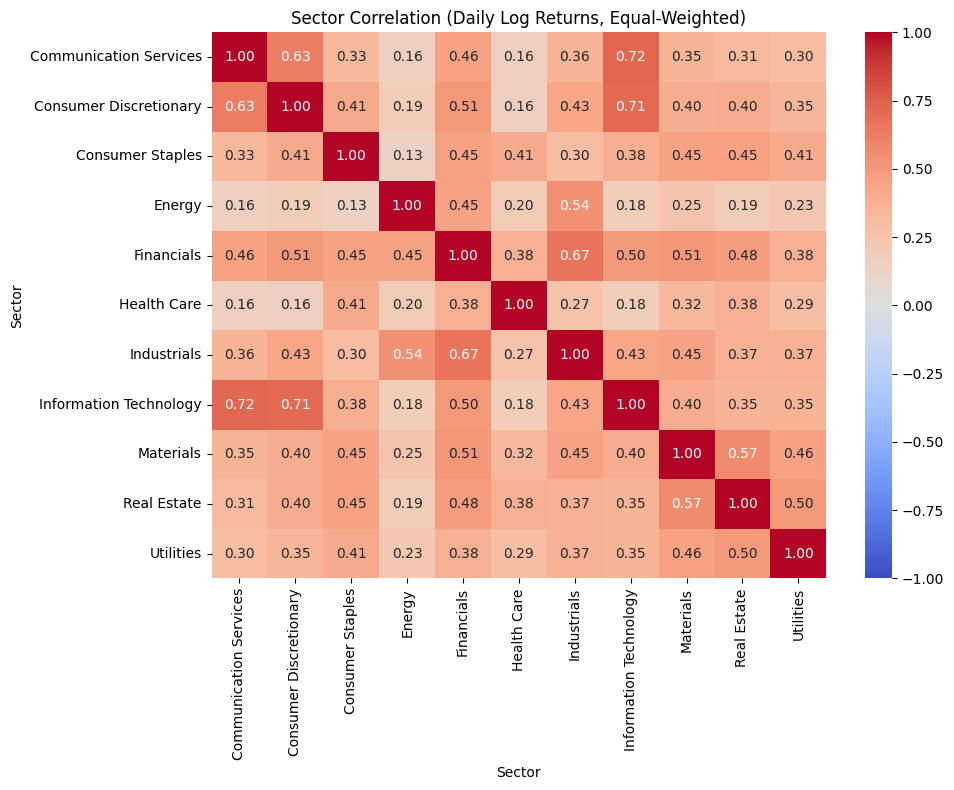

In [56]:
# Sector daily log-return (equal-weight across stocks)
ret_log = sp500_subset2.dropna(subset=["LogReturn"])

sector_daily_log = (
    ret_log.groupby(["Date", "Sector"])["LogReturn"]
           .mean()
           .unstack("Sector")
           .sort_index()
)

sector_corr_log = sector_daily_log.corr()
print("Sector correlation (LogReturns):")
display(sector_corr_log.round(3))

import seaborn as sns, matplotlib.pyplot as plt
plt.figure(figsize=(10, 8))
sns.heatmap(sector_corr_log, annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1)
plt.title("Sector Correlation (Daily Log Returns, Equal-Weighted)")
plt.tight_layout()
plt.show()

In [57]:
# ----------------------------------------
# 1. Build ticker → sector mapping
# ----------------------------------------
sector_map = (
    sp500_subset[["Symbol", "Sector"]]
    .drop_duplicates(subset="Symbol")
    .set_index("Symbol")["Sector"]
)

# ----------------------------------------
# 2. Add Sector into weighted summary
# ----------------------------------------
weighted_summary = weighted_summary.merge(
    sector_map.rename("Sector"),
    on="Symbol",
    how="left"
)

# ----------------------------------------
# 3. Build sector-level correlation score
# ----------------------------------------
sector_corr_score = sector_corr_log.mean(axis=1)

# ----------------------------------------
# 4. Convert to per-ticker correlation score (length = 33)
# ----------------------------------------
corr_score_ticker = weighted_summary["Sector"].map(sector_corr_score)
corr_score = corr_score_ticker.values
np.save("corr_score.npy", corr_score)

print("corr_score shape =", corr_score.shape)

corr_score shape = (33,)


In [58]:
# ============================================================
# EXPORT weighted_summary2 for optimization in VS Code
# ============================================================

mu_annual = weighted_summary["W_Annual_Return"].values
sigma_annual = weighted_summary["W_Annual_SD"].values
tickers = weighted_summary["Symbol"].tolist()

np.save("mu_annual.npy", mu_annual)
np.save("sigma_annual.npy", sigma_annual)
pd.Series(tickers).to_csv("tickers.csv", index=False)

print("Exported: mu_annual.npy, sigma_annual.npy, tickers.csv")


Exported: mu_annual.npy, sigma_annual.npy, tickers.csv


In [59]:
print("Min weighted annual SD:", weighted_summary["W_Annual_SD"].min())
print("Max weighted annual SD:", weighted_summary["W_Annual_SD"].max())
print("Median weighted annual SD:", weighted_summary["W_Annual_SD"].median())

Min weighted annual SD: 0.1677991128903937
Max weighted annual SD: 0.6175028196589601
Median weighted annual SD: 0.2511521800829071


In [60]:
print(sp500_subset.columns)
print(sp500_subset.head())

Index(['Date', 'Close', 'High', 'Low', 'Open', 'Volume', 'Symbol', 'Security',
       'Sector', 'Weight'],
      dtype='object')
        Date      Close       High        Low       Open    Volume Symbol  \
0 2020-11-23  84.081802  84.559074  83.168406  83.884313   7541500   ABBV   
1 2020-11-24  85.546516  86.254193  84.410945  84.657805   9322200   ABBV   
2 2020-11-25  85.744026  85.957977  85.077496  85.431334   6368100   ABBV   
3 2020-11-27  86.311798  87.060621  85.826302  86.385860   4418800   ABBV   
4 2020-11-30  86.056725  86.747940  85.291446  86.501080  20726500   ABBV   

  Security       Sector  Weight  
0   AbbVie  Health Care   0.007  
1   AbbVie  Health Care   0.007  
2   AbbVie  Health Care   0.007  
3   AbbVie  Health Care   0.007  
4   AbbVie  Health Care   0.007  


In [61]:
# Export sp500_subset2 to CSV
sp500_subset2.to_csv("sp500_subset2_export.csv", index=False)

Stock-level correlation matrix shape: (33, 33)


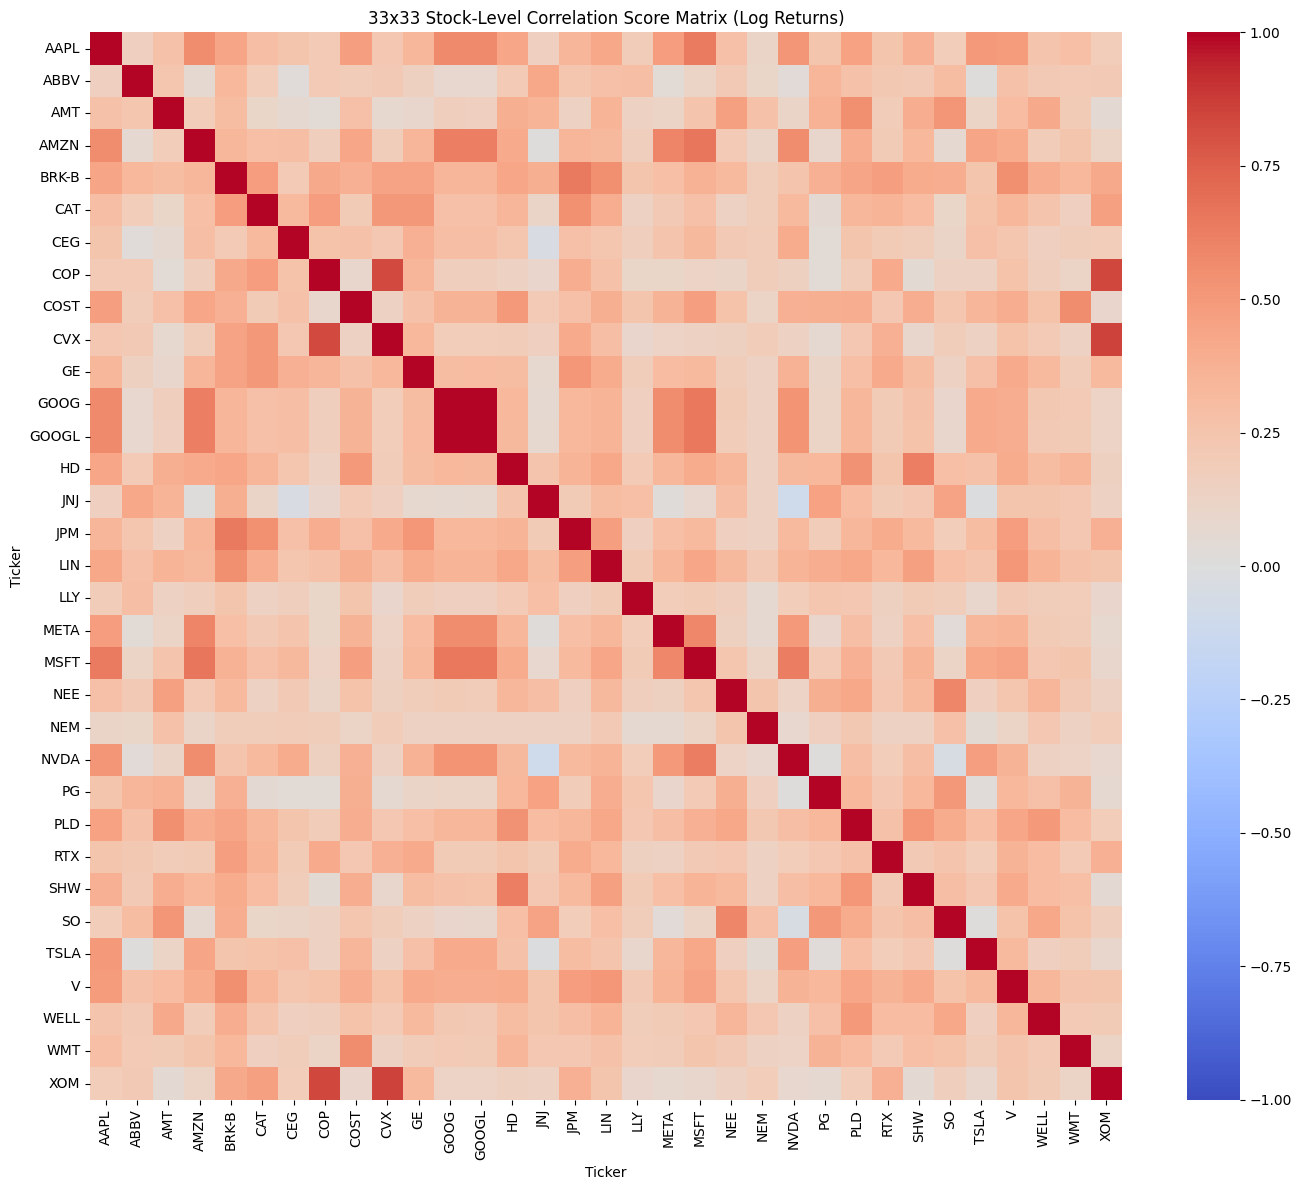

In [62]:
# --- Compute and save 33x33 stock-level correlation score matrix ---
# Pivot daily log returns to wide format (Date x Symbol)
returns_wide = sp500_subset2.pivot(index="Date", columns="Symbol", values="LogReturn").sort_index()
# Drop dates where all tickers are NaN
returns_wide = returns_wide.dropna(how="all")

# Compute stock-level correlation matrix (33x33)
stock_corr_matrix = returns_wide.corr().values
np.save("stock_corr_matrix.npy", stock_corr_matrix)

print("Stock-level correlation matrix shape:", stock_corr_matrix.shape)

# Plot heatmap
import matplotlib.pyplot as plt
import seaborn as sns
tickers = returns_wide.columns.tolist()
plt.figure(figsize=(14, 12))
sns.heatmap(stock_corr_matrix, annot=False, cmap="coolwarm", vmin=-1, vmax=1,
            xticklabels=tickers, yticklabels=tickers)
plt.title("33x33 Stock-Level Correlation Score Matrix (Log Returns)")
plt.xlabel("Ticker")
plt.ylabel("Ticker")
plt.tight_layout()
plt.show()

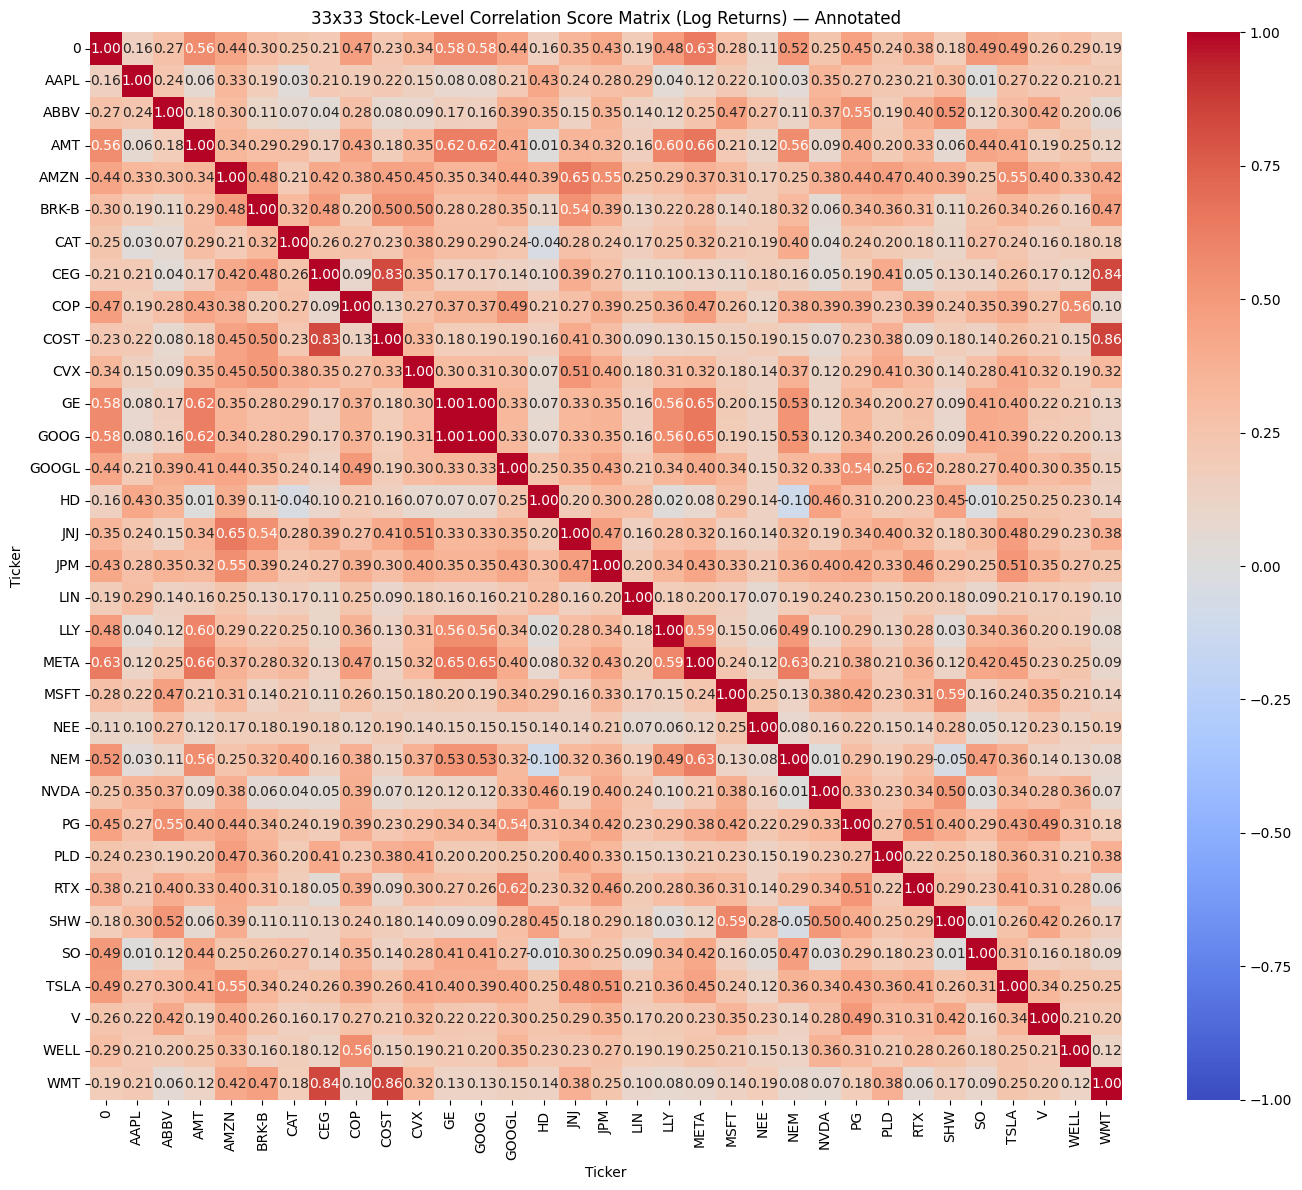

In [63]:
# Annotate heatmap with actual correlation scores (rounded to 2 decimals)
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

corr_matrix = np.load("stock_corr_matrix.npy")
tickers = pd.read_csv("tickers.csv", header=None)[0].astype(str).tolist()

# Ensure tickers list matches matrix shape
if len(tickers) > corr_matrix.shape[0]:
    tickers = tickers[:corr_matrix.shape[0]]
elif len(tickers) < corr_matrix.shape[0]:
    tickers += [f"T{i}" for i in range(len(tickers), corr_matrix.shape[0])]

plt.figure(figsize=(14, 12))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1,
            xticklabels=tickers, yticklabels=tickers)
plt.title("33x33 Stock-Level Correlation Score Matrix (Log Returns) — Annotated")
plt.xlabel("Ticker")
plt.ylabel("Ticker")
plt.tight_layout()
plt.show()

In [64]:
# Summary statistics for the 33x33 stock-level correlation matrix
import numpy as np
import pandas as pd

corr_matrix = np.load("stock_corr_matrix.npy")
tickers = pd.read_csv("tickers.csv", header=None)[0].astype(str).tolist()

# Flatten matrix, exclude diagonal
corr_flat = corr_matrix[~np.eye(corr_matrix.shape[0],dtype=bool)]
lowest = np.min(corr_flat)
highest = np.max(corr_flat)
mean = np.mean(corr_flat)
median = np.median(corr_flat)

print(f"Lowest correlation (off-diagonal): {lowest:.3f}")
print(f"Highest correlation (off-diagonal): {highest:.3f}")
print(f"Mean correlation (off-diagonal): {mean:.3f}")
print(f"Median correlation (off-diagonal): {median:.3f}")

Lowest correlation (off-diagonal): -0.095
Highest correlation (off-diagonal): 0.995
Mean correlation (off-diagonal): 0.273
Median correlation (off-diagonal): 0.255


In [65]:
# Find the pair of tickers with the highest off-diagonal correlation
import numpy as np
import pandas as pd

corr_matrix = np.load("stock_corr_matrix.npy")
tickers = pd.read_csv("tickers.csv", header=None)[0].astype(str).tolist()

# Mask diagonal
mask = ~np.eye(corr_matrix.shape[0], dtype=bool)
corr_flat = corr_matrix[mask]
max_corr = np.max(corr_flat)

# Find indices of highest correlation
max_idx = np.where(corr_matrix == max_corr)
pairs = [(i, j) for i, j in zip(*max_idx) if i != j]
if pairs:
    i, j = pairs[0]
    print(f"Highest correlation: {max_corr:.3f} between {tickers[i]} and {tickers[j]}")
else:
    print("No off-diagonal correlations found.")

Highest correlation: 0.995 between GE and GOOG


In [66]:
# Break down off-diagonal correlations into quartiles
import numpy as np
import pandas as pd

corr_matrix = np.load("stock_corr_matrix.npy")
tickers = pd.read_csv("tickers.csv", header=None)[0].astype(str).tolist()

# Flatten matrix, exclude diagonal
corr_flat = corr_matrix[~np.eye(corr_matrix.shape[0], dtype=bool)]
quartiles = np.percentile(corr_flat, [0, 25, 50, 75, 100])

print("Correlation quartile breakdown (off-diagonal):")
print(f"Q1 (lowest 25%): {quartiles[0]:.3f} to {quartiles[1]:.3f}")
print(f"Q2 (25%-50%): {quartiles[1]:.3f} to {quartiles[2]:.3f}")
print(f"Q3 (50%-75%): {quartiles[2]:.3f} to {quartiles[3]:.3f}")
print(f"Q4 (highest 25%): {quartiles[3]:.3f} to {quartiles[4]:.3f}")

Correlation quartile breakdown (off-diagonal):
Q1 (lowest 25%): -0.095 to 0.167
Q2 (25%-50%): 0.167 to 0.255
Q3 (50%-75%): 0.255 to 0.357
Q4 (highest 25%): 0.357 to 0.995
